<a href="https://colab.research.google.com/github/kathulapravachana19-cloud/Audio_Sound_Reducer1/blob/main/Audio_Noise_Reducer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip -q install scipy soundfile

import numpy as np
import matplotlib.pyplot as plt
import soundfile as sf
from scipy import signal
from IPython.display import Audio, display

In [ ]:
# ==============================
# AUDIO INPUT / BENCHMARK
# ==============================

sample_rate = 16000
duration = 3

t = np.linspace(
    0,
    duration,
    int(sample_rate * duration),
    endpoint=False
)

# Original clean signal
clean_original = (
    0.50 * np.sin(2 * np.pi * 440 * t) +
    0.30 * np.sin(2 * np.pi * 660 * t) +
    0.20 * np.sin(2 * np.pi * 880 * t)
)

# Add noise
np.random.seed(42)

noise_level = 0.25
noise = noise_level * np.random.randn(len(t))

# Noisy audio
noisy_audio = clean_original + noise

print("Audio created successfully!")
print("Duration:", duration, "seconds")
print("Sample Rate:", sample_rate, "Hz")
print("Noise Level:", noise_level)

# Play noisy audio
print("\n🔊 Noisy Audio:")
display(Audio(noisy_audio, rate=sample_rate))

Audio created successfully!
Duration: 3 seconds
Sample Rate: 16000 Hz
Noise Level: 0.25

🔊 Noisy Audio:


In [ ]:
# ==============================
# USER CONFIGURATION
# ==============================

N_FFT = 1024
HOP_LENGTH = 256

# Change this value and observe the result
SVD_RANK = 40

print("FFT Size    :", N_FFT)
print("Hop Length  :", HOP_LENGTH)
print("SVD Rank    :", SVD_RANK)

FFT Size    : 1024
Hop Length  : 256
SVD Rank    : 40


In [ ]:
# ==============================
# STFT
# ==============================

frequencies, times, Zxx = signal.stft(
    noisy_audio,
    fs=sample_rate,
    nperseg=N_FFT,
    noverlap=N_FFT - HOP_LENGTH
)

A = Zxx

print("STFT Matrix Shape:", A.shape)

STFT Matrix Shape: (513, 189)


In [ ]:
# ==============================
# SVD MATHEMATICAL ENGINE
# ==============================

U, singular_values, Vh = np.linalg.svd(
    A,
    full_matrices=False
)

print("SVD completed successfully!")

print("\nFirst 10 Singular Values:")
print(singular_values[:10])

SVD completed successfully!

First 10 Singular Values:
[4.18507549 2.5168143  1.73448591 0.3996239  0.38901418 0.38239528
 0.37682764 0.37376472 0.36923135 0.36675926]


In [ ]:
# ==============================
# NOISE REDUCTION USING SVD
# ==============================

rank = min(SVD_RANK, len(singular_values))

# Keep only largest singular values
U_r = U[:, :rank]
S_r = singular_values[:rank]
Vh_r = Vh[:rank, :]

# Reconstruct reduced-rank matrix
A_clean = U_r @ np.diag(S_r) @ Vh_r

print("Original Rank :", len(singular_values))
print("Selected Rank :", rank)
print("Removed       :", len(singular_values) - rank)

Original Rank : 189
Selected Rank : 40
Removed       : 149


In [ ]:
# ==============================
# INVERSE STFT
# ==============================

_, cleaned_audio = signal.istft(
    A_clean,
    fs=sample_rate,
    nperseg=N_FFT,
    noverlap=N_FFT - HOP_LENGTH
)

# Match original length
cleaned_audio = cleaned_audio[:len(noisy_audio)]

# Normalize
cleaned_audio = cleaned_audio / (
    np.max(np.abs(cleaned_audio)) + 1e-12
)

print("Clean audio reconstructed successfully!")

print("\n🔊 CLEANED AUDIO:")
display(Audio(cleaned_audio, rate=sample_rate))

Clean audio reconstructed successfully!

🔊 CLEANED AUDIO:


In [ ]:
# ==============================
# RESULT
# ==============================

original_energy = np.sum(noisy_audio ** 2)
cleaned_energy = np.sum(cleaned_audio ** 2)

print("\n====================================")
print("       SVD AUDIO NOISE REDUCER")
print("====================================")

print("Sample Rate       :", sample_rate, "Hz")
print("Duration          :", duration, "seconds")
print("STFT Matrix       :", A.shape)
print("Original Rank     :", len(singular_values))
print("Selected Rank     :", rank)
print("Removed Components:", len(singular_values) - rank)

print("------------------------------------")
print("Original Energy   :", round(original_energy, 4))
print("Cleaned Energy    :", round(cleaned_energy, 4))
print("====================================")


       SVD AUDIO NOISE REDUCER
Sample Rate       : 16000 Hz
Duration          : 3 seconds
STFT Matrix       : (513, 189)
Original Rank     : 189
Selected Rank     : 40
Removed Components: 149
------------------------------------
Original Energy   : 12115.6448
Cleaned Energy    : 5332.4168


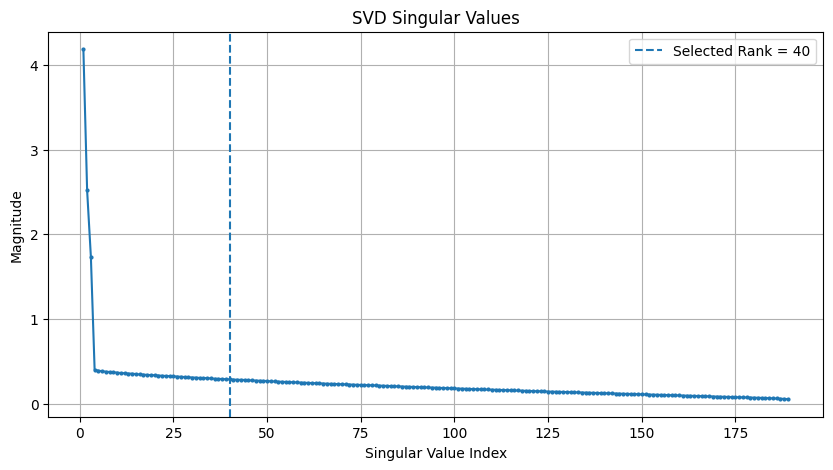

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    range(1, len(singular_values) + 1),
    singular_values,
    marker='o',
    markersize=2
)

plt.axvline(
    rank,
    linestyle='--',
    label=f"Selected Rank = {rank}"
)

plt.title("SVD Singular Values")
plt.xlabel("Singular Value Index")
plt.ylabel("Magnitude")
plt.legend()
plt.grid(True)

plt.show()

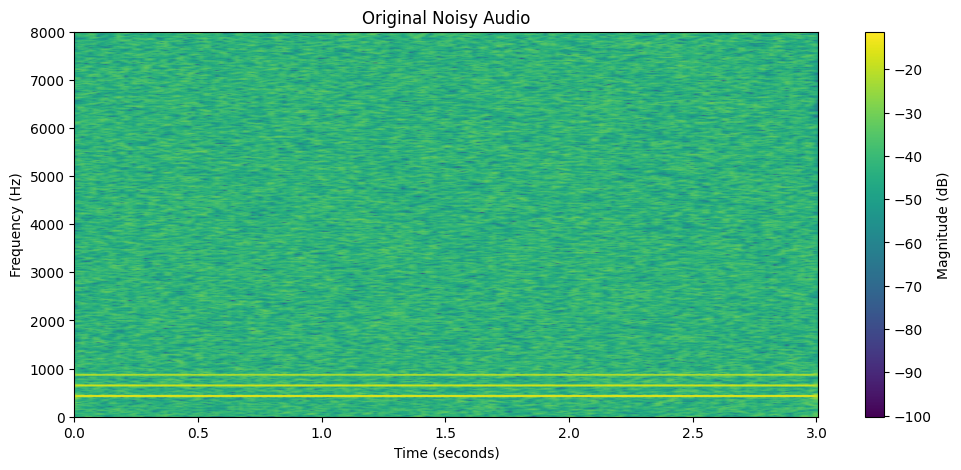

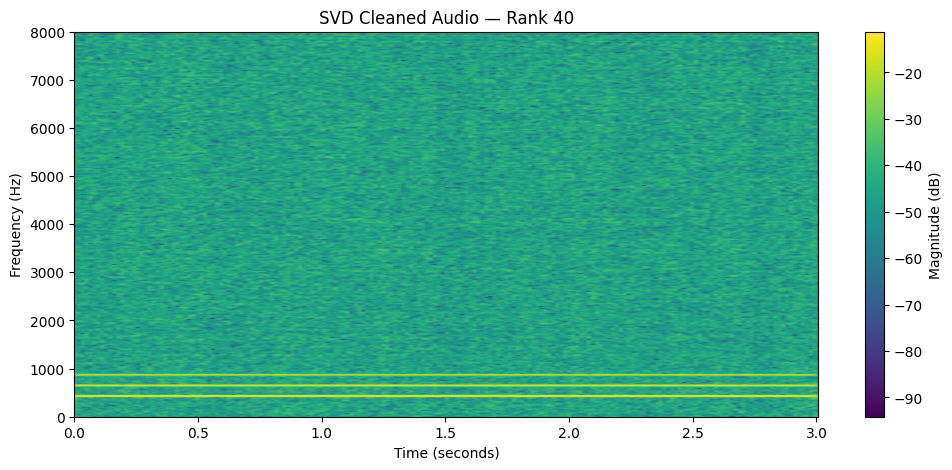

In [ ]:
# ==============================
# SPECTROGRAM COMPARISON
# ==============================

original_db = 20 * np.log10(
    np.abs(A) + 1e-10
)

clean_db = 20 * np.log10(
    np.abs(A_clean) + 1e-10
)

plt.figure(figsize=(12, 5))

plt.pcolormesh(
    times,
    frequencies,
    original_db,
    shading='gouraud'
)

plt.colorbar(label="Magnitude (dB)")
plt.title("Original Noisy Audio")
plt.xlabel("Time (seconds)")
plt.ylabel("Frequency (Hz)")
plt.show()


plt.figure(figsize=(12, 5))

plt.pcolormesh(
    times,
    frequencies,
    clean_db,
    shading='gouraud'
)

plt.colorbar(label="Magnitude (dB)")
plt.title(f"SVD Cleaned Audio — Rank {rank}")
plt.xlabel("Time (seconds)")
plt.ylabel("Frequency (Hz)")
plt.show()

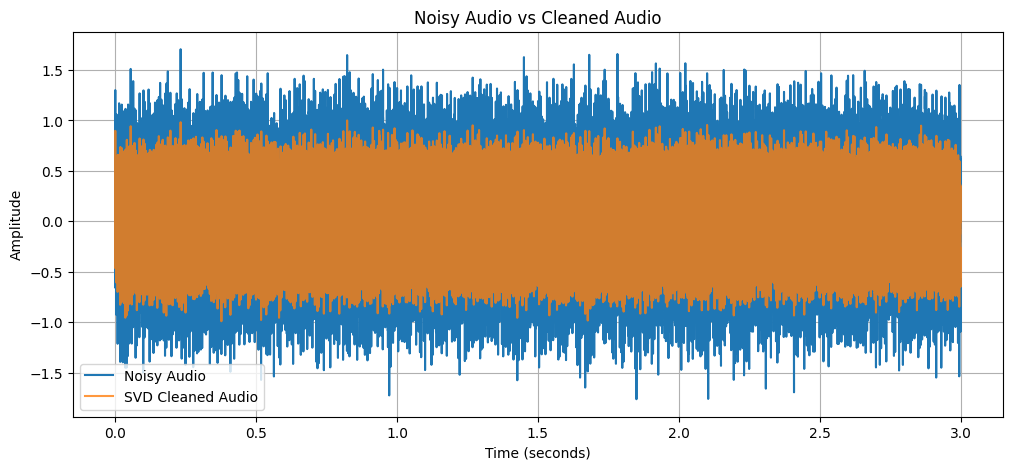

In [ ]:
time_axis = np.arange(len(noisy_audio)) / sample_rate

plt.figure(figsize=(12, 5))

plt.plot(
    time_axis,
    noisy_audio,
    label="Noisy Audio"
)

plt.plot(
    time_axis,
    cleaned_audio,
    label="SVD Cleaned Audio",
    alpha=0.8
)

plt.title("Noisy Audio vs Cleaned Audio")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
# ==============================
# SAVE RESULT
# ==============================

output_file = "SVD_Cleaned_Audio.wav"

sf.write(
    output_file,
    cleaned_audio,
    sample_rate
)

print("✅ Clean audio saved as:", output_file)

✅ Clean audio saved as: SVD_Cleaned_Audio.wav
